---
tags: [integration, optimization, variational]
---

# CUDA-Q Support

This page shows how to use Qamomile's [CUDA-Q](https://nvidia.github.io/cuda-quantum/latest/) quantum SDK integration through a concrete optimization problem.
In this tutorial, we use QAOA optimization for a small MaxCut instance as an example. We transpile a Qamomile qkernel to CUDA-Q, then run sampling and expectation-value evaluation.
`CudaqExecutor` uses the currently active CUDA-Q target. By default, CUDA-Q's local CPU simulator is used, so the examples below run on a local CPU without any extra configuration.
Later, we run the same QAOA circuit on the CPU target (`qpp-cpu`) and GPU target (`nvidia`) and compare the sampled results and execution time.
Along the way, we inspect the generated CUDA-Q source and compare Qamomile's `STATIC` and `RUNNABLE` CUDA-Q execution modes.

In [ ]:
# Install Qamomile with the CUDA-Q extras through pip.
# Choose the optional dependency group that matches your CUDA-Q environment.
# !pip install "qamomile[cudaq-cu12]"  # CUDA 12.x, Linux
# !pip install "qamomile[cudaq-cu13]"  # CUDA 13.x, Linux or macOS ARM64

In [2]:
import os
import platform
import subprocess
import time
from collections import Counter

import cudaq
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.cudaq import CudaqExecutor, CudaqTranspiler, ExecutionMode
from qamomile.optimization.binary_model import BinaryModel

## The MaxCut problem

We use the same small 5-node graph from the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb) so the focus stays on the CUDA-Q integration.
Maximizing $\sum_{(i,j) \in E}(1 - s_i s_j)/2$ is equivalent, up to a constant, to *minimizing* the antiferromagnetic Ising Hamiltonian $H_C = \sum_{(i,j) \in E} s_i s_j$.
For unweighted MaxCut, every $J_{ij} = 1$ and every $h_i = 0$, so we pass these coefficients directly to `BinaryModel.from_ising`.
We use the model object for the `quad` / `linear` dictionaries passed to the QAOA qkernel and for decoding measurements back into spin values $(+1 / -1)$.

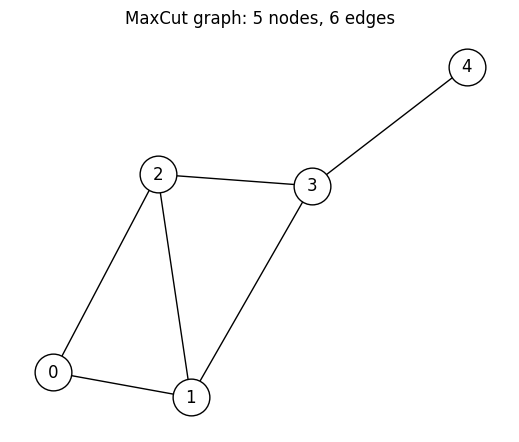

In [3]:
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)
# The problem structure is fully determined by the graph: one quad term per edge
# and no linear terms for unweighted MaxCut. Assert so a regression in
# `BinaryModel.from_ising` is caught when this notebook runs in CI.
assert len(spin_model.quad) == G.number_of_edges()
assert len(spin_model.linear) == 0

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## Building the QAOA ansatz with `@qkernel`

We write the sampling QAOA ansatz as reusable qkernels.
The recipe is the same as in the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb). After preparing a uniform superposition in the computational basis, we alternately apply cost and mixer layers $p$ times, then measure in the computational basis.

:::{tip}
Qamomile's rotation gates follow the $e^{-i\theta/2}$ convention.
Because of that, the $1/2$ factor is handled slightly differently in the cost and mixer layers.
In the mixer layer, we pass $2\beta$ to `rx`, so the $1/2$ cancels and we get the textbook $e^{-i\beta X}$.
In the cost layer, we pass $J_{ij} \cdot \gamma$ to `rzz`, so the $1/2$ remains.
We absorb this coefficient difference into the variational parameter $\gamma$: the $\gamma$ used here is twice the textbook QAOA $\gamma$.
:::

In [4]:
@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

`qaoa_ansatz.draw(...)` renders the Qamomile circuit diagram.
We pass concrete values for the arguments that determine the problem structure (`p`, `quad`, `linear`, `n`) so the layered shape is visible.
Meanwhile, `gammas` / `betas` are left as parameters whose values are supplied later.

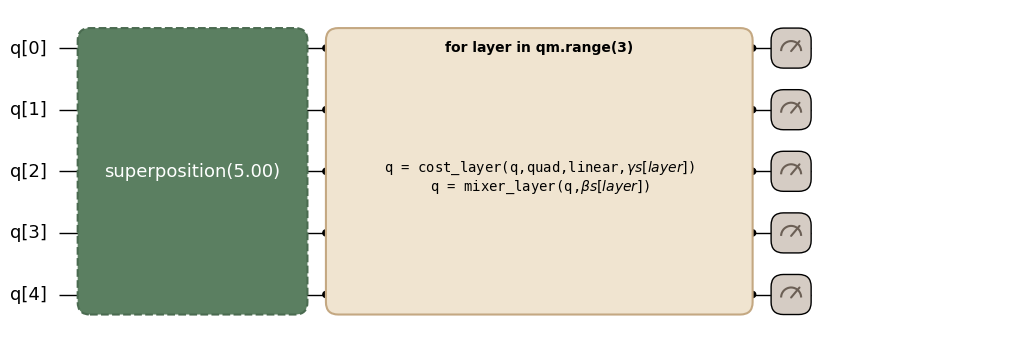

In [5]:
p = 3  # number of QAOA layers
qaoa_ansatz.draw(
    p=p,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
)

## Transpile to CUDA-Q

`CudaqTranspiler` is used with `transpile()` the same way as any other quantum SDK.
We bind the arguments that determine the problem structure and keep `gammas` / `betas` as runtime parameters.

In [6]:
transpiler = CudaqTranspiler()
executor = CudaqExecutor()

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`executable.get_first_circuit()` returns Qamomile's generated CUDA-Q artifact, `CudaqKernelArtifact`.
This is a Qamomile-side wrapper for the generated `@cudaq.kernel` function, not a type from the upstream `cudaq` Python package.
The artifact keeps an inspectable Python source string for the generated CUDA-Q kernel. The $2p$ QAOA angles (`gammas[0..p-1]`, `betas[0..p-1]`) remain available as named runtime parameters.
We can confirm that with `type(...)`, the qubit count, and the parameter count, then inspect the generated source.
This source string is useful when you want to see exactly what Qamomile handed to CUDA-Q, including gate decompositions such as the `rzz` layer below.

In [ ]:
cudaq_artifact = executable.get_first_circuit()
assert cudaq_artifact is not None  # transpile() always emits one quantum segment here
# `num_qubits` and `param_count` are fully determined by the problem setting:
# one qubit per graph node, and one runtime parameter per (gamma | beta) per layer.
assert cudaq_artifact.num_qubits == num_nodes
assert cudaq_artifact.param_count == 2 * p
assert cudaq_artifact.execution_mode == ExecutionMode.STATIC
assert len(executable.parameter_names) == 2 * p
print(type(cudaq_artifact).__name__)
print("execution_mode :", cudaq_artifact.execution_mode.value)
print("num_qubits     :", cudaq_artifact.num_qubits)
print("param_count    :", cudaq_artifact.param_count)
print("parameter_names:", executable.parameter_names)

assert "@cudaq.kernel" in cudaq_artifact.source
assert "x.ctrl" in cudaq_artifact.source
assert "rz(" in cudaq_artifact.source
print(cudaq_artifact.source)

CudaqKernelArtifact
execution_mode : static
num_qubits     : 5
param_count    : 6
parameter_names: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
@cudaq.kernel
def _qamomile_kernel(thetas: list[float]):
    q = cudaq.qvector(5)
    __b0 = False
    __b1 = False
    __b2 = False
    __b3 = False
    __b4 = False
    h(q[0])
    h(q[1])
    h(q[2])
    h(q[3])
    h(q[4])
    x.ctrl(q[0], q[1])
    rz((1.0) * (thetas[0]), q[1])
    x.ctrl(q[0], q[1])
    x.ctrl(q[0], q[2])
    rz((1.0) * (thetas[0]), q[2])
    x.ctrl(q[0], q[2])
    x.ctrl(q[1], q[2])
    rz((1.0) * (thetas[0]), q[2])
    x.ctrl(q[1], q[2])
    x.ctrl(q[1], q[3])
    rz((1.0) * (thetas[0]), q[3])
    x.ctrl(q[1], q[3])
    x.ctrl(q[2], q[3])
    rz((1.0) * (thetas[0]), q[3])
    x.ctrl(q[2], q[3])
    x.ctrl(q[3], q[4])
    rz((1.0) * (thetas[0]), q[4])
    x.ctrl(q[3], q[4])
    rx((thetas[1]) * (2.0), q[0])
    rx((thetas[1]) * (2.0), q[1])
    rx((thetas[1]) * (2.0), q[2])
    rx((thetas[1

Each runtime parameter remains unbound until execution time.
That means binding `gammas` / `betas` is treated as a parameter-value update on the CUDA-Q side rather than a circuit rebuild.
The problem structure, such as the Ising coefficients, qubit count, and number of layers, is fixed when the circuit is transpiled, leaving only the variational angles as runtime inputs.

## Sampling QAOA with `CudaqExecutor`

`executable.sample(executor, bindings=..., shots=...)` returns a `SampleJob`.
Calling `.result()` gives a `SampleResult`, which `BinaryModel.decode_from_sampleresult` decodes into a `BinarySampleSet` of spin variables $(+1 / -1)$.
This lets us count cut edges without any additional conversion.
`CudaqExecutor()` runs against the currently active CUDA-Q target; by default that is CUDA-Q's local CPU simulator.

In [8]:
rng = np.random.default_rng(42)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

# Sample the parameterized executable and decode bitstrings to Ising energies.
sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = spin_model.decode_from_sampleresult(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")

Mean energy at random init: -0.6480


## Optimizing the QAOA parameters

A QAOA optimization loop reuses the same `executable` across many `(gammas, betas)` vectors.
Call `transpiler.transpile()` once, then call `executable.sample()` many times.
In this example, we define the sampling and decoding work as `cost_fn()` and optimize it with SciPy's `minimize` function.
The classical optimizer updates `(gammas, betas)` while lowering the mean sampled Ising energy.
Each iteration reuses the same `executable` and `CudaqExecutor`.

In [9]:
# Reuse one executable inside the classical objective function.
cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = spin_model.decode_from_sampleresult(result).energy_mean()
    cost_history.append(energy)
    return energy


# Optimize the sampled mean energy with COBYLA.
res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")

Optimized mean energy: -2.5450
Optimal gammas       : [1.7064, -1.0342, 1.0672]
Optimal betas        : [0.021, -1.8938, 1.4447]


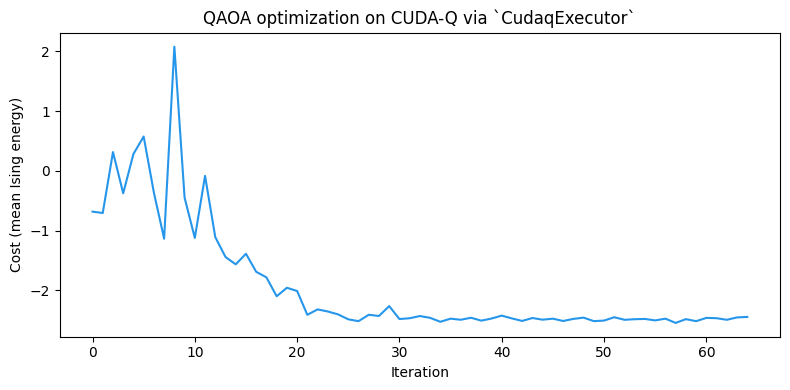

In [10]:
# Plot the objective values collected during optimization.
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on CUDA-Q via `CudaqExecutor`")
plt.tight_layout()
plt.show()

Sampling is probabilistic, and different CUDA-Q targets can use different simulator implementations.
Because of that, the optimization trajectory and final sampled energy may vary slightly across runs.
The optimizer should still converge close to the ground-state energy of $H_C$ on this 5-node graph.
The optimized parameters from this run (`opt_gammas`, `opt_betas`) are reused throughout the rest of this page.

## Expectation values

In Qamomile, you write expectation values in a qkernel with `qmc.expval(...)`.
When this is transpiled to CUDA-Q, it becomes an executable object that can be called with `ExecutableProgram.run(executor, bindings=...)`.
For CUDA-Q, `run()` uses Qamomile's recorded parameter information to bind runtime parameters before calling CUDA-Q's `observe` API.

We first use Qamomile's `run()` path, then open the lower-level path that passes the generated CUDA-Q artifact directly to `executor.estimate(...)`.

### `run()`

First build a Qamomile `Hamiltonian` for $H_C = \sum_{(i,j) \in E} Z_i Z_j$.
Then transpile the expectation-value qkernel and evaluate it at the optimized QAOA parameters.

In [11]:
cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

# Define the expectation-value qkernel.
@qmc.qkernel
def qaoa_expval(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    obs: qmc.Observable,
) -> qmc.Float:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.expval(q, obs)


# Transpile the expectation-value qkernel and evaluate it with `run()`.
expval_executable = transpiler.transpile(
    qaoa_expval,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
        "obs": cost_hamiltonian,
    },
    parameters=["gammas", "betas"],
)
energy_from_run = expval_executable.run(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
).result()

print(f"ExecutableProgram.run: {energy_from_run:+.10f}")
assert np.isfinite(energy_from_run)

ExecutableProgram.run: -2.4711464893


`ExecutableProgram.run(...)` is the recommended route when you work through the Qamomile API.
The observable and named runtime parameter bindings are managed by Qamomile's `ExecutableProgram`.

The next section opens the lower-level path and passes the CUDA-Q artifact emitted by `transpile()` directly to `executor.estimate(...)`.

### `cudaq.observe`

For `STATIC` CUDA-Q artifacts, `CudaqExecutor.estimate(circuit, hamiltonian, params=...)` calls `cudaq.observe()` under the hood.
The measured QAOA ansatz above is still usable as a state-preparation circuit because Qamomile does not write terminal measurements into the generated CUDA-Q kernel for `STATIC` artifacts.
Sampling handles the final measurement separately, so the same emitted artifact can also be used by `cudaq.observe()`.
In a QAOA optimizer, you can keep the same circuit and replace `ExecutableProgram.sample()` plus decoding with `executor.estimate(circuit, hamiltonian, params=...)`.

When calling `executor.estimate(...)` directly, you provide the flat parameter order expected by the CUDA-Q artifact yourself.

In [12]:
unbound_circuit = executable.get_first_circuit()
assert unbound_circuit is not None
assert unbound_circuit.execution_mode == ExecutionMode.STATIC
print(f"artifact type       : {type(unbound_circuit).__name__}")
print(f"artifact param_count: {unbound_circuit.param_count}")

# CUDA-Q requires the runtime parameters as a flat list in the order
# they were registered on the artifact, which is the first-use order during
# circuit emission. For QAOA that means gammas[0], betas[0], gammas[1], betas[1],
# ..., interleaved per layer, NOT all gammas followed by all betas.
# Read the order from the `ExecutableProgram` and build the flat list by lookup so
# we never have to guess the convention.
named_values = {f"gammas[{i}]": opt_gammas[i] for i in range(p)}
named_values.update({f"betas[{i}]": opt_betas[i] for i in range(p)})
flat_params = [named_values[name] for name in executable.parameter_names]
# The runtime parameter set is the 2p QAOA angles.
assert len(executable.parameter_names) == 2 * p
assert len(flat_params) == 2 * p
print(f"artifact parameter order: {executable.parameter_names}")

energy_via_estimate = executor.estimate(
    unbound_circuit, cost_hamiltonian, params=flat_params
)
print(f"executor.estimate: {energy_via_estimate:+.10f}")
assert np.isclose(energy_from_run, energy_via_estimate, atol=1e-10)

artifact type       : CudaqKernelArtifact
artifact param_count: 6
artifact parameter order: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
executor.estimate: -2.4711464893


The `run()` and `executor.estimate(...)` paths agree to numerical precision.
They evaluate the same QAOA state against the same Ising cost Hamiltonian.
The resulting noise-free expectation value at the optimized parameters should also match the sample-mean energy printed earlier within shot noise.

## Choosing CUDA-Q targets: Using the GPU target

`CudaqExecutor()` uses the current CUDA-Q target, while `CudaqExecutor(target=...)` or `CudaqTranspiler.executor(target=...)` selects a target explicitly.
The custom executor can be used anywhere `executor` appeared above.
Changing the CUDA-Q target does not require re-transpiling the kernel.
The `ExecutableProgram` carries the emitted CUDA-Q artifact, while the executor chooses the target used at execution time.
The list of simulator targets you can select is maintained in CUDA-Q's [Circuit Simulation](https://nvidia.github.io/cuda-quantum/latest/using/simulators.html) documentation, and CUDA-Q's [Running on a GPU](https://nvidia.github.io/cuda-quantum/latest/using/basics/run_kernel.html#running-on-a-gpu) section shows the same `qpp-cpu` / `nvidia` target pattern directly.

:::{note}
This tutorial also works well in Google Colab.
To try the GPU target there, choose a GPU runtime before running the notebook, install the CUDA-Q extras that match the runtime, and then run the cells below.
CUDA-Q uses `qpp-cpu` as the CPU simulator target and `nvidia` as the local NVIDIA GPU simulator target.
:::

As a concrete example, we sample the same optimized QAOA `ExecutableProgram` on the CPU and GPU targets.
Both runs below are noise-free: we do not install a CUDA-Q noise model, and each target uses the same QAOA circuit and the same parameter vector.
We also set the same CUDA-Q random seed before each sampling call.
The finite-shot samples are still produced by each target's simulator, so we compare the sampled mean energies with a tolerance and plot the energy histograms rather than relying on identical raw shot ordering.
We also time the sampling call on each target.

In [13]:
benchmark_shots = 512 if docs_test_mode else 100_000
benchmark_seed = 13


def cpu_backend_info() -> str:
    processor = platform.processor() or platform.machine() or "unknown processor"
    if os.path.exists("/proc/cpuinfo"):
        with open("/proc/cpuinfo", encoding="utf-8") as cpuinfo:
            for line in cpuinfo:
                if line.startswith("model name"):
                    processor = line.split(":", maxsplit=1)[1].strip()
                    break
    return f"{processor}; logical CPUs: {os.cpu_count()}"


def gpu_backend_info() -> str:
    try:
        completed = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            check=True,
            capture_output=True,
            text=True,
            timeout=5,
        )
    except (
        FileNotFoundError,
        subprocess.CalledProcessError,
        subprocess.TimeoutExpired,
    ):
        return f"{cudaq.num_available_gpus()} CUDA-Q GPU(s) available"

    names = [line.strip() for line in completed.stdout.splitlines() if line.strip()]
    return ", ".join(names) if names else "NVIDIA GPU detected"


def timed_qaoa_sample(target_name: str):
    cudaq.set_target(target_name)
    cudaq.set_random_seed(benchmark_seed)
    start = time.perf_counter()
    result = executable.sample(
        CudaqExecutor(),
        bindings={"gammas": opt_gammas, "betas": opt_betas},
        shots=benchmark_shots,
    ).result()
    return result, time.perf_counter() - start

In [14]:
# CPU target (qpp-cpu)
target_runs = []
cpu_result, cpu_seconds = timed_qaoa_sample("qpp-cpu")
cpu_decoded = spin_model.decode_from_sampleresult(cpu_result)
cpu_energy = cpu_decoded.energy_mean()
target_runs.append(("qpp-cpu", cpu_decoded, cpu_energy, cpu_seconds, "#2696EB"))
print("CPU backend target  : qpp-cpu")
print(f"CPU hardware        : {cpu_backend_info()}")
print(f"CPU qpp-cpu mean energy: {cpu_energy:+.4f}")
print(f"CPU qpp-cpu sample time: {cpu_seconds:.4f} s")

CPU backend target  : qpp-cpu
CPU hardware        : Intel(R) Xeon(R) CPU @ 2.00GHz; logical CPUs: 2
CPU qpp-cpu mean energy: -2.4646
CPU qpp-cpu sample time: 0.1291 s


In [15]:
# GPU target (nvidia)
if cudaq.num_available_gpus() > 0 and cudaq.has_target("nvidia"):
    gpu_result, gpu_seconds = timed_qaoa_sample("nvidia")
    gpu_decoded = spin_model.decode_from_sampleresult(gpu_result)
    gpu_energy = gpu_decoded.energy_mean()
    target_runs.append(("nvidia GPU", gpu_decoded, gpu_energy, gpu_seconds, "#FF8A3D"))
    print("GPU backend target  : nvidia")
    print(f"GPU hardware        : {gpu_backend_info()}")
    print(f"GPU nvidia mean energy: {gpu_energy:+.4f}")
    print(f"GPU nvidia sample time: {gpu_seconds:.4f} s")
    print(f"CPU/GPU time ratio    : {cpu_seconds / gpu_seconds:.2f}x")
else:
    gpu_decoded = None
    print(
        "No NVIDIA GPU was detected. Run this notebook in a Google Colab GPU "
        "runtime to execute the `nvidia` target."
    )

cudaq.reset_target()

GPU backend target  : nvidia
GPU hardware        : Tesla T4
GPU nvidia mean energy: -2.4798
GPU nvidia sample time: 0.1033 s
CPU/GPU time ratio    : 1.25x


When a GPU is available, the CPU and GPU samples should describe the same QAOA output distribution.
The helper below visualizes the sampled energy histograms and checks that the mean energies remain close.
The tolerances are deliberately finite-shot tolerances, not exact-equality checks; the common seed makes the comparison reproducible for each target implementation.

mean-energy difference: 0.0152


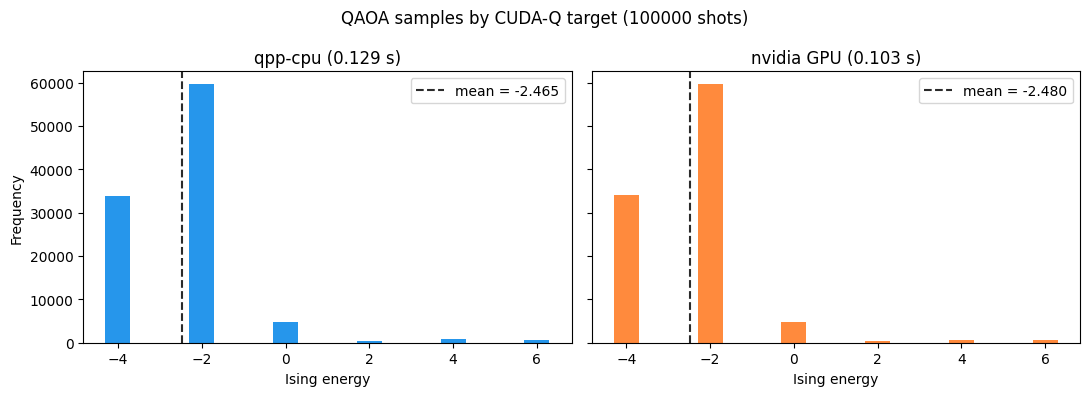

In [ ]:
def energy_distribution(decoded_samples):
    counts: Counter[float] = Counter()
    for energy, occ in zip(decoded_samples.energy, decoded_samples.num_occurrences):
        counts[energy] += occ
    energies = sorted(counts.keys())
    return energies, [counts[energy] for energy in energies]


if gpu_decoded is not None:
    energy_delta = abs(cpu_energy - gpu_energy)
    print(f"mean-energy difference: {energy_delta:.4f}")
    assert energy_delta < (0.5 if docs_test_mode else 0.15)

fig, axes = plt.subplots(
    1,
    len(target_runs),
    figsize=(5.5 * len(target_runs), 4),
    sharey=True,
)
if len(target_runs) == 1:
    axes = [axes]
for ax, (target_name, decoded_samples, mean_energy, elapsed, color) in zip(
    axes, target_runs
):
    energies, counts = energy_distribution(decoded_samples)
    ax.bar(energies, counts, width=0.6, color=color)
    ax.axvline(
        mean_energy,
        color="#2B2B2B",
        linestyle="--",
        linewidth=1.5,
        label=f"mean = {mean_energy:+.3f}",
    )
    ax.set_xticks(energies)
    ax.set_title(f"{target_name} ({elapsed:.3f} s)")
    ax.set_xlabel("Ising energy")
    ax.legend()

axes[0].set_ylabel("Frequency")
fig.suptitle(f"QAOA samples by CUDA-Q target ({benchmark_shots} shots)")
fig.tight_layout()
plt.show()

## When Kernels Include Classical Control Flow: `STATIC` and `RUNNABLE` artifacts

Most variational circuits, including the QAOA ansatz above, transpile to `ExecutionMode.STATIC`.
`STATIC` artifacts have no explicit terminal measurement in the generated CUDA-Q source, so they are compatible with CUDA-Q's `sample` and `observe` APIs.

Qamomile quantum kernels are designed with hardware-level execution in mind and can express classical control flow based on mid-circuit measurement results (see [Classical Flow Patterns](../tutorial/07_classical_flow_patterns.ipynb) for details).
For this reason, if a quantum kernel contains control flow that depends on runtime measurements, such as `if` branches or `while` loops, the CUDA-Q backend emits an `ExecutionMode.RUNNABLE` artifact instead.
`RUNNABLE` artifacts use explicit `mz(...)` measurements in the generated source and execute through `cudaq.run()`.
The following tiny feed-forward circuit demonstrates that path.

In [17]:
@qmc.qkernel
def measurement_feed_forward() -> qmc.Bit:
    q0 = qmc.qubit("q0")
    q1 = qmc.qubit("q1")
    q0 = qmc.x(q0)
    bit = qmc.measure(q0)
    if bit:
        q1 = qmc.x(q1)
    return qmc.measure(q1)


runnable_executable = transpiler.transpile(measurement_feed_forward)
runnable_circuit = runnable_executable.get_first_circuit()
assert runnable_circuit is not None
assert runnable_circuit.execution_mode == ExecutionMode.RUNNABLE
assert "mz(" in runnable_circuit.source
assert "if " in runnable_circuit.source

print("execution_mode:", runnable_circuit.execution_mode.value)
print(runnable_circuit.source)

execution_mode: runnable
@cudaq.kernel
def _qamomile_kernel() -> list[bool]:
    q = cudaq.qvector(2)
    __b0 = False
    __b1 = False
    x(q[0])
    __b0 = mz(q[0])
    if __b0:
        x(q[1])
    __b1 = mz(q[1])
    return [__b0, __b1]



`ExecutableProgram.sample(...)` still works for `RUNNABLE` artifacts, but the executor calls `cudaq.run()` rather than `cudaq.sample()`.
The example above is deterministic: the first measurement is always `1`, so the branch flips `q1` and the returned bit is always `1`.

In [18]:
runnable_shots = 128
runnable_sample = runnable_executable.sample(executor, shots=runnable_shots).result()
print(runnable_sample.results)
assert sum(count for _, count in runnable_sample.results) == runnable_shots
assert all(value == 1 for value, _ in runnable_sample.results)

[(1, 128)]


The trade-off is that `RUNNABLE` artifacts are not compatible with CUDA-Q's `observe` API.
Qamomile surfaces that distinction as a `TypeError` when `estimate()` is called on a `RUNNABLE` artifact.

In [19]:
try:
    executor.estimate(runnable_circuit, qm_o.Z(0))
except TypeError as exc:
    print(type(exc).__name__, exc)
else:
    raise AssertionError("RUNNABLE CUDA-Q circuits must reject observe()")

TypeError cudaq.observe() is not supported for runtime control flow circuits. Use sample() or run() instead.


## Summary

In this tutorial, we transpiled a MaxCut QAOA quantum kernel to the CUDA-Q backend, then exercised sampling, expectation-value estimation, CPU/GPU target selection, and execution of a circuit with classical control flow.

- The CUDA-Q artifact emitted by `CudaqTranspiler` keeps inspectable Python source and can be reused with runtime parameters.
- The same `ExecutableProgram` can run on the `qpp-cpu` target or the `nvidia` GPU target, with target selection handled by the executor.
- `CudaqExecutor` supports both QAOA-style sampling and noise-free expectation values through CUDA-Q's `observe` API.
- Quantum kernels with classical control flow that depends on runtime measurements are emitted as `ExecutionMode.RUNNABLE` artifacts and execute through `cudaq.run()`.

### See also

- [QURI Parts Support](quri_parts_support.ipynb) covers the same MaxCut QAOA workflow on the QURI Parts backend.
- [Qiskit Support](qiskit_support.ipynb) covers the same workflow on Qiskit, including Aer simulators, Qiskit primitives, and native Qiskit circuit features.